In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize
from scipy.sparse.linalg import expm_multiply, eigsh 
import warnings
warnings.filterwarnings('ignore')

# Quantum chemistry
from pyscf import gto, scf, ao2mo
from openfermion import FermionOperator, normal_ordered, jordan_wigner, get_sparse_operator, count_qubits


## __BUILD HAMILTONIAN__ ##

In [27]:
def build_one_electron(integral, n_orb):
    H = FermionOperator()
    for p in range(n_orb):
        for q in range(n_orb):
            if abs(integral[p, q]) < 1e-12:
                continue
            for sigma in range(2):
                i = 2 * p + sigma 
                j = 2 * q + sigma
                H += FermionOperator(((i, 1), (j, 0)), integral[p, q])
    return H

In [28]:
def build_two_electron(eri_mo, n_orb):
    H = FermionOperator()
    for p in range(n_orb):
        for q in range(n_orb):
            for r in range(n_orb):
                for s in range(n_orb):
                    g = eri_mo[p,q,r,s]
                    if abs(g) < 1e-12:
                        continue
                    for sigma in range(2):
                        for tau in range(2):
                            i = 2 * p + sigma
                            j = 2 * r + tau
                            k = 2 * s + tau
                            l = 2 * q + sigma
                            H += FermionOperator(
                                ((i, 1), (j, 1), (k, 0), (l, 0)),
                                0.5 * g
                            )
    return H

    H_mat  : matriks Hamiltonian elektronik (2^n_q × 2^n_q)
    T_mat  : matriks kinetik
    V_mat  : matriks potensial (Ven + Vee)
    E_nuc  : energi repulsi inti
    n_q    : jumlah qubit
    n_orb  : jumlah orbital spasial

In [29]:
def build_hamiltonian(bond_length, angle_deg=104.5):
    #bangun molekul
    mol = gto.Mole()

    angle = np.radians(angle_deg / 2)
    hx = bond_length * np.sin(angle)
    hz = bond_length * np.cos(angle)
    mol.atom = (f"O 0 0 0; "
                f"H  {hx:.6f} 0  {hz:.6f}; "
                f"H -{hx:.6f} 0  {hz:.6f}")
    mol.basis = 'sto-3g'
    mol.verbose = 0
    mol.build()

    #hartree-fock
    mf = scf.RHF(mol)
    mf.run()
    C = mf.mo_coeff
    n_orb = C.shape[1]
    E_nuc = mol.energy_nuc()
    n_elec = mol.nelectron


    #integral dalam basis MO
    #T_ao = mol.intor('int1e_kin')
    #V_ao = mol.intor('int1e_nuc')
    #T_mo  = C.T @ T_ao @ C
    #V_mo  = C.T @ V_ao @ C
    #eri_mo = ao2mo.kernel(mol, C, compact=False).reshape(n_orb, n_orb, n_orb, n_orb)

    #integral full sebelum dipotong
    h_ao = mol.intor('int1e_kin') + mol.intor('int1e_nuc')
    h_mo = C.T @ h_ao @ C
    eri_mo = ao2mo.kernel(mol, C, compact=False).reshape(
                            n_orb, n_orb, n_orb, n_orb)
    
    #freeze 1 core orbital
    ncore = 1           #orbital 0 1s di freeze

    #hitung energi frozen core
    E_core = 0.0
    for c in range(ncore):
        E_core += 2 * h_mo[c,c]
        for c2 in range(ncore):
            E_core += (2 * eri_mo[c,c,c2,c2] - 
                       eri_mo[c, c2, c2, c])
    
    nact = n_orb - ncore
    h_eff = h_mo[ncore:, ncore:].copy()
    for p in range(nact):
        for q in range(nact):
            for c in range(ncore):
                h_eff[p,q] += (2 * eri_mo[p+ncore, q+ncore, c, c] -
                               eri_mo[p+ncore, c, c, q+ncore])

    #pisah T dan V dari h_eff
    T_mo_full = C.T @ mol.intor('int1e_kin') @ C
    V_mo_full = C.T @ mol.intor('int1e_nuc') @ C
    T_eff = T_mo_full[ncore:, ncore:]
    V_eff = h_eff - T_eff
    T_mo  = T_eff
    V_mo  = V_eff

    eri_act = eri_mo[ncore:, ncore:, ncore:, ncore:]
    n_orb   = nact
    n_elec  = mol.nelectron - 2 * ncore
    E_nuc = mol.energy_nuc() + E_core

    #operator fermion
    H_Kin = normal_ordered(build_one_electron(T_mo, n_orb))
    H_VeN = normal_ordered(build_one_electron(V_mo, n_orb))
    H_Vee = normal_ordered(build_two_electron(eri_mo, n_orb))
    
    # Jordan-Wigner → operator qubit
    T_q   = jordan_wigner(H_Kin)
    VeN_q = jordan_wigner(H_VeN)
    Vee_q = jordan_wigner(H_Vee)
    V_q   = VeN_q + Vee_q
    n_q   = count_qubits(T_q + V_q)

    # Dense matrix
    T_sp = get_sparse_operator(T_q, n_qubits=n_q).tocsr()
    V_sp = get_sparse_operator(V_q, n_qubits=n_q).tocsr()
    H_sp = (T_sp + V_sp).tocsr()

    return H_sp, T_sp, V_sp, E_nuc, n_q, n_orb, n_elec

In [30]:
# ── Uji cepat pada panjang ikatan ekuilibrium ───────────────────────
print("Membangun Hamiltonian untuk R = 0.97 Å ...")
H_test, T_test, V_test, E_nuc_test, n_q_test, n_orb_test, n_elec_test = build_hamiltonian(0.97)

evals_test, _ = eigsh(H_test, k=1, which='SA')
E_exact_test  = evals_test[0] + E_nuc_test

print(f"  Orbital spasial   : {n_orb_test}")
print(f"  Jumlah qubit      : {n_q_test}")
print(f"  Dimensi Hilbert   : {2**n_q_test} × {2**n_q_test}")
print(f"  E_nuc             : {E_nuc_test:.6f} Ha")
print(f"  E_exact (FCI)     : {E_exact_test:.6f} Ha")

Membangun Hamiltonian untuk R = 0.97 Å ...
  Orbital spasial   : 6
  Jumlah qubit      : 12
  Dimensi Hilbert   : 4096 × 4096
  E_nuc             : -51.559169 Ha
  E_exact (FCI)     : -74.427841 Ha


## __QUANTUM CIRCUIT: ANSATZ__ ##

In [31]:
def _apply_gate_1q(psi, gate, qubit, n_qubits):
    """Terapkan gate 2×2 pada satu qubit via moveaxis — O(2^n), tanpa matriks besar."""
    psi = psi.reshape([2] * n_qubits)
    psi = np.moveaxis(psi, qubit, 0)          # bawa qubit target ke axis-0
    psi = gate @ psi.reshape(2, -1)           # kalikan gate 2×2
    psi = psi.reshape([2] * n_qubits)
    psi = np.moveaxis(psi, 0, qubit)          # kembalikan ke posisi semula
    return psi.reshape(-1)

#gate primitives
def ry_gate(psi, theta, qubit, n_qubits):
    c, s = np.cos(theta / 2), np.sin(theta / 2)
    gate = np.array([[c, -s], [s, c]], dtype=complex)
    return _apply_gate_1q(psi, gate, qubit, n_qubits)

def cnot_full(psi, control, target, n_qubits):
    psi   = psi.reshape([2] * n_qubits)
    psi   = np.moveaxis(psi, [control, target], [0, 1])  # ctrl→ax0, tgt→ax1
    shape = psi.shape
    psi   = psi.reshape(2, 2, -1).copy()
    psi[1] = psi[1, ::-1, :]                             # flip target saat ctrl=1
    psi   = psi.reshape(shape)
    psi   = np.moveaxis(psi, [0, 1], [control, target])  # kembalikan
    return psi.reshape(-1)

In [32]:
#inisialisasi state dengan hartee fock
def prepare_hf_state(n_qubits, n_electrons):
    psi = np.zeros(2 ** n_qubits, dtype=complex)
    hf_idx = sum(1 << (n_qubits - 1 - i) for i in range(n_electrons))
    psi[hf_idx] = 1.0
    return psi

    params      : array parameter θ (panjang = n_qubits × (depth+1))
    n_qubits    : jumlah qubit
    n_electrons : jumlah elektron (untuk inisialisasi HF state)
    depth       : jumlah lapisan Ry-CNOT
    cnot_layer  : matrix CNOT entangling (precomputed)

In [33]:
#hardware efficient ansantz
def prepare_ansatz(params, n_qubits, n_electrons, depth):
    psi = prepare_hf_state(n_qubits, n_electrons)
    idx = 0

    for d in range(depth + 1):
        # Lapisan Ry pada semua qubit secara berurutan
        for q in range(n_qubits):
            psi  = ry_gate(psi, params[idx], q, n_qubits)
            idx += 1

        # Lapisan CNOT entangling (kecuali setelah Ry layer terakhir)
        if d < depth:
            for q in range(n_qubits - 1):
                psi = cnot_full(psi, q, q+1, n_qubits)
    return psi

In [34]:
# ── Konfigurasi Global ───────────────────────────────────────────────
N_QUBITS    = 12          # 2 orbital spasial × 2 spin = 4 qubit
N_ELECTRONS = 8           # H₂ memiliki 2 elektron
DEPTH       = 4           # kedalaman ansatz
N_PARAMS    = N_QUBITS * (DEPTH + 1)   # = 60 parameter

# Verifikasi HF state
psi_hf_demo = prepare_hf_state(N_QUBITS, N_ELECTRONS)
hf_index    = np.argmax(np.abs(psi_hf_demo))

print(f"Konfigurasi ansatz:")
print(f"  n_qubits    = {N_QUBITS}")
print(f"  n_electrons = {N_ELECTRONS}")
print(f"  depth       = {DEPTH}")
print(f"  n_params    = {N_PARAMS}  (Ry rotations)")
print(f"  HF state    = |1100⟩  (index {hf_index} dari {2**N_QUBITS} basis states)")


Konfigurasi ansatz:
  n_qubits    = 12
  n_electrons = 8
  depth       = 4
  n_params    = 60  (Ry rotations)
  HF state    = |1100⟩  (index 4080 dari 4096 basis states)


## __BUILD VQE__ ##

In [35]:
#nilai ekspektasi
def expect_value(psi, H_sp):
    return float(np.real(psi.conj() @ H_sp @ psi))

    params      : parameter ansatz θ saat ini (array float)
    H_mat       : matriks Hamiltonian elektronik
    n_qubits    : jumlah qubit
    n_electrons : jumlah elektron
    depth       : kedalaman ansatz
    cnot_layer  : precomputed CNOT matrix
    history     : list yang akan diisi dengan nilai E tiap iterasi

In [36]:
#optimizer klasik untuk menghitung E(0) dan menyimpan riwayat energi tiap iterasi
def optimizer_cl(params, H_sp, n_qubits, n_electrons, depth, history):
    psi = prepare_ansatz(params, n_qubits, n_electrons, depth)
    E = expect_value(psi, H_sp)
    history.append(E)
    return E

Jalankan VQE: minimasi E(θ) = ⟨ψ(θ)|H|ψ(θ)⟩ dengan optimizer klasik.

In [37]:
def run_vqe(H_sp, n_qubits, n_electrons, depth=2, method='COBYLA', 
            n_restarts=5, seed=42, verbose=False):

    rng      = np.random.RandomState(seed)
    n_params = n_qubits * (depth + 1)
    best     = {'E_vqe': np.inf, 'energy_history': [], 'n_iters': 0}

    opts_map = {
        'COBYLA'     : {'maxiter': max(10000, 150 * n_params), 'rhobeg': 0.3},
        'Nelder-Mead': {'maxiter': 5000, 'xatol': 1e-8, 'fatol': 1e-8},
        'BFGS'       : {'maxiter': 1000, 'gtol': 1e-8},
        'L-BFGS-B'   : {'maxiter': 1000, 'ftol': 1e-12},
    }
    opts = opts_map.get(method, {'maxiter': 2000})

    for trial in range(n_restarts):
        history = []
        # Paruh pertama: θ₀ kecil (dekat identitas → dekat HF state)
        # Paruh kedua : θ₀ lebar (eksplorasi ruang parameter)
        theta0 = (rng.uniform(-0.3, 0.3, n_params) if trial < n_restarts // 2
                  else rng.uniform(-np.pi, np.pi, n_params))
        
        if verbose:
            print(f"  [Restart {trial+1}/{n_restarts}] "
                  f"n_params={n_params}, method={method}")
            
        iter_count = [0]
        def callback(theta):
            iter_count[0] += 1
            if verbose and iter_count[0] % 50 == 0 and history:
                print(f"    iter {iter_count[0]:4d} | E = {history[-1]:.8f} Ha")

        try:
            res = minimize(
                optimizer_cl,
                theta0,
                args=(H_sp, n_qubits, n_electrons, depth, history),
                method=method,
                callback=callback,
                options=opts
        )
        except Exception as exc:
            print(f"  [!] Restart {trial+1} error: {exc}")
            continue

        if verbose:
            print(f"  → selesai: E={res.fun:.8f} Ha | "
                  f"{len(history)} evals | success={res.success}")

        if res.fun < best['E_vqe']:
            best = {
                'E_vqe'          : res.fun,
                'optimal_params' : res.x.copy(),
                'energy_history' : history.copy(),
                'n_iters'        : len(history),
                'trial'          : trial + 1,
                'success'        : res.success
            }
    return best

## __MENCOBA VQE PADA BOND LENGTH EKUILIBRIUM (R = 0.74 Å)__ ##

In [38]:
R_DEMO = 0.96  # Å — panjang ikatan ekuilibrium H₂O

print(f"  VQE Demo: H₂O, R = {R_DEMO} Å, Basis STO-3G")

  VQE Demo: H₂O, R = 0.96 Å, Basis STO-3G


In [39]:
#hamiltonian
H_demo, T_demo, V_demo, E_nuc_demo, n_q_demo, _, n_elec_demo = \
    build_hamiltonian(R_DEMO) 
print(f"\n[1] Hamiltonian: n_qubits={n_q_demo}, dim={2**n_q_demo}×{2**n_q_demo}")

#energi eksak (FCI diagonalisasi)
evals_d, evecs_d = eigsh(H_demo, k=1, which='SA')
E_exact_d = evals_d[0] + E_nuc_demo
print(f"[2] E_exact (FCI)  = {E_exact_d:.8f} Ha")

#energi hartee fock pada ansatz theta=0
psi_hf_d = prepare_hf_state(n_q_demo, n_elec_demo)
E_hf_d = expect_value(psi_hf_d, H_demo) + E_nuc_demo
print(f"[3] E_HF (θ=0)     = {E_hf_d:.8f} Ha  |  error = {abs(E_hf_d - E_exact_d):.2e} Ha")

#jalanin VQE
vqe_d = run_vqe(
    H_demo, n_q_demo, n_elec_demo,
    depth      = DEPTH,
    method     = 'COBYLA',
    n_restarts = 3,
    seed       = 42,
    verbose    = True
)

E_vqe_d  = vqe_d['E_vqe'] + E_nuc_demo
err_vqe_d = abs(E_vqe_d - E_exact_d)
corr_pct  = (E_hf_d - E_vqe_d) / (E_hf_d - E_exact_d) * 100

print(f"\n[4] Hasil Akhir VQE:")
print(f"    E_VQE   = {E_vqe_d:.8f} Ha")
print(f"    E_exact = {E_exact_d:.8f} Ha")
print(f"    |ΔE|    = {err_vqe_d:.2e} Ha")


[1] Hamiltonian: n_qubits=12, dim=4096×4096
[2] E_exact (FCI)  = -74.38341579 Ha
[3] E_HF (θ=0)     = -68.04017035 Ha  |  error = 6.34e+00 Ha
  [Restart 1/3] n_params=60, method=COBYLA
    iter   50 | E = -13.60843050 Ha
    iter  100 | E = -17.37043109 Ha
    iter  150 | E = -18.14735336 Ha
    iter  200 | E = -18.99756008 Ha
    iter  250 | E = -19.59001281 Ha
    iter  300 | E = -20.24011275 Ha
    iter  350 | E = -20.94593078 Ha
    iter  400 | E = -21.14524319 Ha
    iter  450 | E = -21.24875833 Ha
    iter  500 | E = -21.44479328 Ha
    iter  550 | E = -21.50357214 Ha
    iter  600 | E = -21.59713784 Ha
    iter  650 | E = -21.61825168 Ha
    iter  700 | E = -21.72070632 Ha
    iter  750 | E = -21.76711114 Ha
    iter  800 | E = -21.78495731 Ha
    iter  850 | E = -21.82297158 Ha
    iter  900 | E = -21.87253316 Ha
    iter  950 | E = -21.89291630 Ha
    iter 1000 | E = -21.91923418 Ha
    iter 1050 | E = -21.92306661 Ha
    iter 1100 | E = -21.93030731 Ha
    iter 1150 | E = -2

In [40]:
# Fidelity
psi_opt_d    = prepare_ansatz(vqe_d['optimal_params'], n_q_demo,
                               n_elec_demo, DEPTH)
psi_exact_d  = evecs_d[:, 0]
fidelity_d   = abs(psi_opt_d.conj() @ psi_exact_d) ** 2
print(f"    Fidelity |⟨ψ_VQE|ψ_FCI⟩|² = {fidelity_d:.6f}")

    Fidelity |⟨ψ_VQE|ψ_FCI⟩|² = 0.002969


## __KURVA ENERGI POTENSIAL__ ##

In [41]:
#trotterisasi
def suzuki_trotter(T_sp, V_sp, psi0, dt, n_steps):
    """
    Second-order Suzuki-Trotter time evolution U(t) = e^{-iHt}.
    
    Evolusi waktu orde-2 Suzuki-Trotter: U(dt)^n_steps |ψ₀⟩
    Menggunakan expm_multiply → tidak membangun matriks 2^n × 2^n.
    """
    psi = psi0.astype(complex).copy()
    for _ in range(n_steps):
        psi  = expm_multiply(-1j * (dt / 2) * V_sp, psi)
        psi  = expm_multiply(-1j * dt * T_sp, psi)
        psi  = expm_multiply(-1j * (dt / 2) * V_sp, psi)
    psi /= np.linalg.norm(psi) 
    return psi

In [42]:
bond_lengths = np.array([
    0.5, 0.6, 0.7, 0.74, 0.8, 0.9, 1.0,
    1.2, 1.4, 1.6, 1.8, 2.0, 2.4, 2.8, 3.0
])

DT      = 0.05
N_STEPS = 20

In [43]:
#looping
results = []
CHEM_ACC = 1.6e-3   # Hartree
print(f"{'─'*77}")
print(f"  {'R(Å)':>5} │ {'E_exact(Ha)':>13} │ {'E_VQE(Ha)':>13} │ "
      f"{'E_Trotter(Ha)':>13} │ {'|ΔE_VQE|(Ha)':>12}")
print(f"{'─'*77}")

for R in bond_lengths:
    #hamiltonian 
    H_sp, T_sp, V_sp, E_nuc, n_q, _, n_elec = build_hamiltonian(R)

    #eksak
    evals, evecs = eigsh(H_sp, k=1, which='SA')
    E_exact      = evals[0] + E_nuc
    psi0         = evecs[:, 0].astype(complex)

    #VQE
    vqe_res = run_vqe(H_sp, n_q, n_elec,
                      depth=DEPTH, method='COBYLA',
                      n_restarts=5, seed=42, verbose=False)
    E_vqe   = vqe_res['E_vqe'] + E_nuc
    delta_v = abs(E_vqe - E_exact)

    #suzuki-trotter
    psi_trot = suzuki_trotter(T_sp, V_sp, psi0, DT, N_STEPS)
    E_trot   = expect_value(psi_trot, H_sp) + E_nuc
    delta_t  = abs(E_trot - E_exact)

    results.append({
        'bond_length'   : R,
        'E_exact'       : E_exact,
        'E_vqe'         : E_vqe,
        'E_trotter'     : E_trot,
        'delta_vqe'     : delta_v,
        'delta_trotter' : delta_t,
        'n_iters_vqe'   : vqe_res['n_iters'],
        'history_vqe'   : vqe_res['energy_history'],
        'E_nuc'         : E_nuc,
    })

    print(f"  {R:5.2f}   │  {E_exact:11.6f}  │  {E_vqe:11.6f}  │  "
          f"{E_trot:11.6f}  │  {delta_v:.2e}")

─────────────────────────────────────────────────────────────────────────────
   R(Å) │   E_exact(Ha) │     E_VQE(Ha) │ E_Trotter(Ha) │ |ΔE_VQE|(Ha)
─────────────────────────────────────────────────────────────────────────────
   0.50   │   -72.674691  │   -71.447523  │   -72.674688  │  1.23e+00
   0.60   │   -74.323671  │   -72.904150  │   -74.323668  │  1.42e+00
   0.70   │   -75.349172  │   -73.427609  │   -75.349170  │  1.92e+00
   0.74   │   -73.165192  │   -72.495531  │   -73.165192  │  6.70e-01
   0.80   │   -73.560290  │   -72.856286  │   -73.560290  │  7.04e-01
   0.90   │   -74.102804  │   -73.313479  │   -74.102804  │  7.89e-01
   1.00   │   -74.557738  │   -73.598411  │   -74.557738  │  9.59e-01
   1.20   │   -75.325519  │   -74.184658  │   -75.325518  │  1.14e+00
   1.40   │   -75.632123  │   -74.574281  │   -75.632123  │  1.06e+00
   1.60   │   -76.435550  │   -74.893213  │   -76.435550  │  1.54e+00
   1.80   │   -76.644061  │   -75.199480  │   -76.644061  │  1.44e+00
   

In [50]:
df = pd.DataFrame([{
    'R (Å)'          : f"{r['bond_length']:.2f}",
    'E_exact (Ha)'   : f"{r['E_exact']:.6f}",
    'E_VQE (Ha)'     : f"{r['E_vqe']:.6f}",
    'E_Trotter (Ha)' : f"{r['E_trotter']:.6f}",
    '|ΔE_VQE| (Ha)'  : f"{r['delta_vqe']:.2e}",
    '|ΔE_Trot| (Ha)' : f"{r['delta_trotter']:.2e}",
    'Iter VQE'       : r['n_iters_vqe'],
    'Chem.Acc.'      : '✓' if r['delta_vqe'] < 1.6e-3 else '✗',
} for r in results])

print("Tabel Perbandingan Lengkap:")
print(df.to_string(index=False))

Tabel Perbandingan Lengkap:
R (Å) E_exact (Ha) E_VQE (Ha) E_Trotter (Ha) |ΔE_VQE| (Ha) |ΔE_Trot| (Ha)  Iter VQE Chem.Acc.
 0.50   -72.674691 -71.447523     -72.674688      1.23e+00       2.74e-06     10000         ✗
 0.60   -74.323671 -72.904150     -74.323668      1.42e+00       2.49e-06     10000         ✗
 0.70   -75.349172 -73.427609     -75.349170      1.92e+00       1.95e-06     10000         ✗
 0.74   -73.165192 -72.495531     -73.165192      6.70e-01       4.24e-07     10000         ✗
 0.80   -73.560290 -72.856286     -73.560290      7.04e-01       3.71e-07     10000         ✗
 0.90   -74.102804 -73.313479     -74.102804      7.89e-01       3.38e-07     10000         ✗
 1.00   -74.557738 -73.598411     -74.557738      9.59e-01       3.47e-07     10000         ✗
 1.20   -75.325519 -74.184658     -75.325518      1.14e+00       3.85e-07     10000         ✗
 1.40   -75.632123 -74.574281     -75.632123      1.06e+00       4.42e-07     10000         ✗
 1.60   -76.435550 -74.893213   

In [51]:
# Statistik ringkas
dv = np.array([r['delta_vqe']     for r in results])
dt = np.array([r['delta_trotter'] for r in results])
print(f"\n{'─'*55}")
print(f"Statistik Error Energi:")
print(f"{'':20s} {'VQE':>12}   {'Suzuki-Trotter':>14}")
print(f"{'─'*55}")
print(f"{'Rata-rata |ΔE|':20s} {np.mean(dv):12.2e}   {np.mean(dt):14.2e} Ha")
print(f"{'Maksimum |ΔE|':20s} {np.max(dv):12.2e}   {np.max(dt):14.2e} Ha")
print(f"{'Minimum |ΔE|':20s} {np.min(dv):12.2e}   {np.min(dt):14.2e} Ha")
print(f"{'─'*55}")


───────────────────────────────────────────────────────
Statistik Error Energi:
                              VQE   Suzuki-Trotter
───────────────────────────────────────────────────────
Rata-rata |ΔE|           9.81e-01         7.22e-07 Ha
Maksimum |ΔE|            1.92e+00         2.74e-06 Ha
Minimum |ΔE|             2.74e-02         4.76e-08 Ha
───────────────────────────────────────────────────────


## __PLOT KURVA ENERGI POTENSIAL__ ##

In [52]:
# Cek dengan print dulu:
R_arr  = np.array([r['bond_length'] for r in results])
E_ex   = np.array([r['E_exact']     for r in results])
E_vq   = np.array([r['E_vqe']       for r in results])
E_tr   = np.array([r['E_trotter']   for r in results])
dv_arr = np.array([r['delta_vqe']   for r in results])
dt_arr = np.array([r['delta_trotter'] for r in results])

idx_min = np.argmin(E_ex)   # ← sekarang aman
print(f"DEBUG: idx_min={idx_min}, R={R_arr[idx_min]}, E={E_ex[idx_min]}")

DEBUG: idx_min=14, R=3.0, E=-78.11417160820301


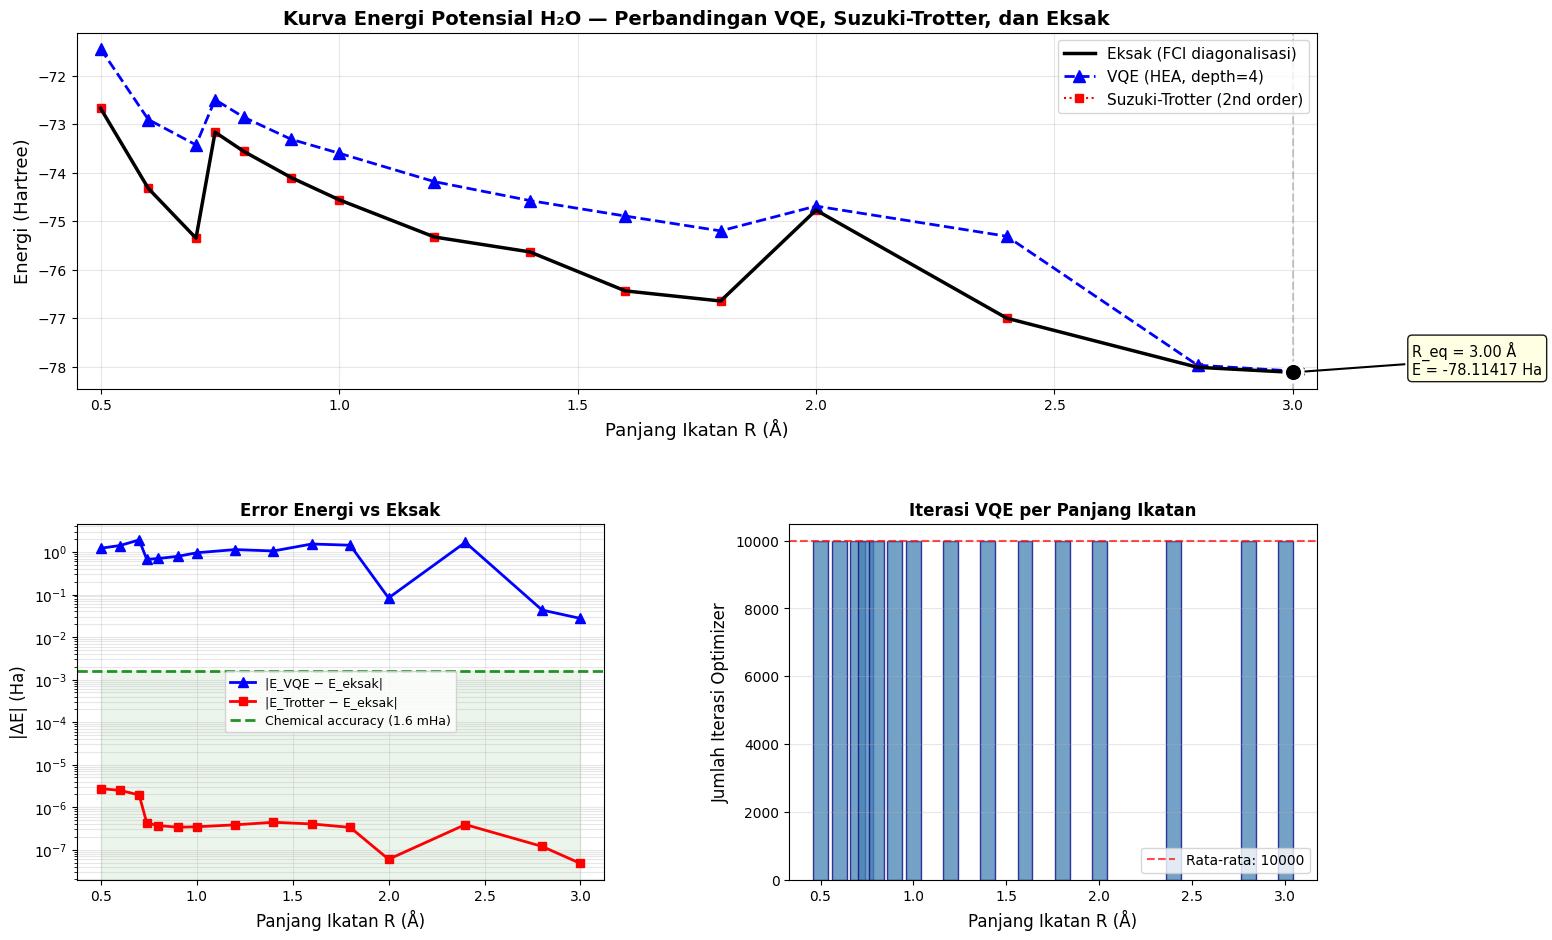

In [53]:
R_arr  = np.array([r['bond_length']   for r in results])
E_ex   = np.array([r['E_exact']        for r in results])
E_vq   = np.array([r['E_vqe']          for r in results])
E_tr   = np.array([r['E_trotter']      for r in results])
dv_arr = np.array([r['delta_vqe']      for r in results])
dt_arr = np.array([r['delta_trotter']  for r in results])

fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(2, 2, hspace=0.38, wspace=0.35)

# ── 1: Kurva energi potensial ────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(R_arr, E_ex, 'k-',   lw=2.5, zorder=5, label='Eksak (FCI diagonalisasi)')
ax1.plot(R_arr, E_vq, 'b^--', lw=2.0, ms=8,  zorder=4, label=f'VQE (HEA, depth={DEPTH})')
ax1.plot(R_arr, E_tr, 'rs:',  lw=1.5, ms=6,  zorder=3, label='Suzuki-Trotter (2nd order)')

# Tandai minimum eksak
idx_min = np.argmin(E_ex)
R_eq    = R_arr[idx_min]      # = 1.0
E_eq    = E_ex[idx_min]       # = -75.01985
ax1.axvline(R_arr[idx_min], color='gray', ls='--', alpha=0.4, lw=1.5)
ax1.scatter([R_arr[idx_min]], [E_ex[idx_min]], s=180, color='black',
            zorder=10, edgecolor='white', lw=2.5)
ax1.annotate(f'R_eq = {R_eq:.2f} Å\nE = {E_eq:.5f} Ha',   # ← pakai variabel
            xy     = (R_eq, E_eq),
            xytext = (R_eq + 0.25, E_eq - 0.04),
            fontsize=10.5, color='black',
            bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.9),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

ax1.set_xlabel('Panjang Ikatan R (Å)', fontsize=13)
ax1.set_ylabel('Energi (Hartree)', fontsize=13)
ax1.set_title('Kurva Energi Potensial H₂O — Perbandingan VQE, Suzuki-Trotter, dan Eksak',
              fontsize=14, weight='bold')
ax1.legend(fontsize=11, loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(R_arr[0]-0.05, R_arr[-1]+0.05)

# ── 2: Log error vs eksak ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.semilogy(R_arr, dv_arr, 'b^-', lw=2, ms=7, label='|E_VQE − E_eksak|')
ax2.semilogy(R_arr, dt_arr, 'rs-', lw=2, ms=6, label='|E_Trotter − E_eksak|')
ax2.axhline(1.6e-3, color='green', ls='--', lw=2, alpha=0.85,
            label='Chemical accuracy (1.6 mHa)')
ax2.fill_between(R_arr, 0, 1.6e-3, alpha=0.08, color='green')
ax2.set_xlabel('Panjang Ikatan R (Å)', fontsize=12)
ax2.set_ylabel('|ΔE| (Ha)', fontsize=12)
ax2.set_title('Error Energi vs Eksak', fontsize=12, weight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, which='both')

# ── 3: Jumlah iterasi VQE ────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
bars = ax3.bar(R_arr, [r['n_iters_vqe'] for r in results],
               width=0.08, color='steelblue', alpha=0.75, edgecolor='navy')
ax3.set_xlabel('Panjang Ikatan R (Å)', fontsize=12)
ax3.set_ylabel('Jumlah Iterasi Optimizer', fontsize=12)
ax3.set_title('Iterasi VQE per Panjang Ikatan', fontsize=12, weight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# Anotasi rata-rata
avg_iters = np.mean([r['n_iters_vqe'] for r in results])
ax3.axhline(avg_iters, color='red', ls='--', lw=1.5, alpha=0.7,
            label=f'Rata-rata: {avg_iters:.0f}')
ax3.legend(fontsize=10)

plt.show()


Parameter Optimal θ* pada R = 0.74 Å
───────────────────────────────────────────────────────
  Layer 0: θ[0]=-1.5395  θ[1]=+1.5723  θ[2]=-0.0006  θ[3]=-0.0104  θ[4]=-0.3274  θ[5]=+1.7966  θ[6]=-0.0035  θ[7]=-0.5573  θ[8]=-0.0023  θ[9]=+1.0606  θ[10]=-0.0008  θ[11]=+1.5708  
  Layer 1: θ[12]=+1.6011  θ[13]=-0.0016  θ[14]=+0.0003  θ[15]=+0.0001  θ[16]=+0.0183  θ[17]=-0.0027  θ[18]=-0.0014  θ[19]=+0.0001  θ[20]=+0.0008  θ[21]=-0.0360  θ[22]=-1.5645  θ[23]=-0.0003  
  Layer 2: θ[24]=-0.0005  θ[25]=+0.0200  θ[26]=-0.0003  θ[27]=-0.0014  θ[28]=+0.0001  θ[29]=-0.4701  θ[30]=+0.0056  θ[31]=-0.4528  θ[32]=+0.0000  θ[33]=+0.0045  θ[34]=-1.5732  θ[35]=-1.5419  
  Layer 3: θ[36]=+0.0005  θ[37]=+0.0039  θ[38]=-0.0046  θ[39]=-0.0002  θ[40]=+0.0009  θ[41]=-0.0174  θ[42]=+3.1221  θ[43]=+0.0004  θ[44]=-0.0001  θ[45]=+1.5773  θ[46]=-1.5702  θ[47]=+1.5438  
  Layer 4: θ[48]=+0.0030  θ[49]=-0.9070  θ[50]=+0.0006  θ[51]=+0.0344  θ[52]=-0.0001  θ[53]=+1.8012  θ[54]=+0.0003  θ[55]=-0.0006  θ[56]=+0.0008  θ[

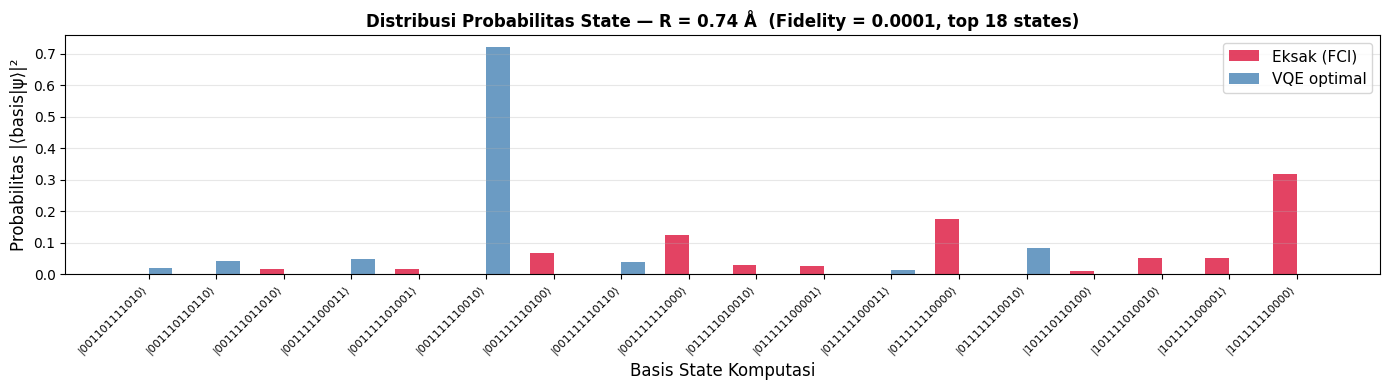

In [54]:
# Analisis Parameter Optimal & Verifikasi Final State (R = 0.74 Å)
# ══════════════════════════════════════════════════════════════════════

# Ambil hasil VQE pada R = 0.74 Å dari sweep
#r_eq = next(r for r in results if r['bond_length'] == 0.74)

# Re-build Hamiltonian untuk mendapatkan H_mat
H_eq, T_eq, V_eq, E_nuc_eq, n_q_eq, _, n_elec_eq = build_hamiltonian(0.74)
vqe_eq    = run_vqe(H_eq, n_q_eq, n_elec_eq,
                    depth=DEPTH, method='COBYLA',
                    n_restarts=5, seed=42, verbose=False)
theta_star = vqe_eq['optimal_params']

print("\nParameter Optimal θ* pada R = 0.74 Å")
print(f"{'─'*55}")
for d in range(DEPTH + 1):
    print(f"  Layer {d}: ", end="")
    for q in range(n_q_eq):
        idx = d * n_q_eq + q
        print(f"θ[{idx}]={theta_star[idx]:+.4f}", end="  ")
    print()
print(f"{'─'*55}")

#eigsh untuk ground state
evals_eq, evecs_eq = eigsh(H_eq, k=1, which='SA')
E_exact_eq         = evals_eq[0] + E_nuc_eq
psi_exact_eq       = evecs_eq[:, 0]

# Verifikasi state optimal
psi_star = prepare_ansatz(theta_star, n_q_eq, n_elec_eq, DEPTH)
E_final  = expect_value(psi_star, H_eq) + E_nuc_eq
fidelity = abs(psi_star.conj() @ psi_exact_eq) ** 2

print(f"\nVerifikasi State Optimal:")
print(f"  E_VQE     = {E_final:.8f} Ha")
print(f"  E_exact   = {E_exact_eq:.8f} Ha")
print(f"  |ΔE|      = {abs(E_final - E_exact_eq):.2e} Ha  "
      f"{'✓ Chemical accuracy' if abs(E_final - E_exact_eq) < CHEM_ACC else '✗'}")
print(f"  Fidelity  = {fidelity:.6f}  (|⟨ψ_VQE|ψ_FCI⟩|²)")
 
# Distribusi probabilitas — [FIX-6] format label sesuai n_q_eq qubit
probs_vqe   = np.abs(psi_star) ** 2
probs_exact = np.abs(psi_exact_eq) ** 2
 
threshold = 0.01
sig_idx   = [i for i in range(len(probs_vqe))
             if probs_vqe[i] > threshold or probs_exact[i] > threshold]

top_n   = 20
sig_idx = sorted(sig_idx, key=lambda i: probs_exact[i] + probs_vqe[i], reverse=True)[:top_n]
sig_idx = sorted(sig_idx)
 
# [FIX-6] Label format sesuai jumlah qubit aktual
fmt = f'0{n_q_eq}b'
basis_labels = [f'|{i:{fmt}}⟩' for i in range(2 ** n_q_eq)]
 
fig2, ax = plt.subplots(figsize=(14, 4))
x, w = np.arange(len(sig_idx)), 0.35
ax.bar(x - w/2, probs_exact[sig_idx], w, label='Eksak (FCI)',  color='crimson',   alpha=0.8)
ax.bar(x + w/2, probs_vqe[sig_idx],   w, label='VQE optimal', color='steelblue', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([basis_labels[i] for i in sig_idx], fontsize=8, rotation=45, ha='right')
ax.set_xlabel('Basis State Komputasi', fontsize=12)
ax.set_ylabel('Probabilitas |⟨basis|ψ⟩|²', fontsize=12)
ax.set_title(
    f'Distribusi Probabilitas State — R = 0.74 Å  '
    f'(Fidelity = {fidelity:.4f}, top {len(sig_idx)} states)',
    fontsize=12, weight='bold'
)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('vqe_state_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## __SOFT__ ##

In [49]:
print(bond_lengths)

[0.5  0.6  0.7  0.74 0.8  0.9  1.   1.2  1.4  1.6  1.8  2.   2.4  2.8
 3.  ]


In [55]:
from scipy.interpolate import CubicSpline

In [56]:
#interpolasi PES VQE ke grid baru
from scipy.interpolate import CubicSpline
R_data = np.array([r['bond_length'] for r in results])
E_data = np.array([r['E_vqe']       for r in results])
E_data -= E_data.min()                        # shift minimum ke 0

# grid SOFT harus mencakup rentang R
d = 6
xMin = R_data.min() - 0.2
#print(xMin)
xMax = R_data.max() + 0.5
#print(xMax)
x = np.linspace(xMin, xMax, num=2**d)

VV = CubicSpline(R_data, E_data)(x)
VV = np.clip(VV, 0, 0.15)
wall = 0.5 * (np.tanh(-(x - xMin - 0.2)*10) +1) * 0.15
VV += wall
print(f'VV = {VV}')

VV = [0.14730207 0.14277778 0.28161352 0.25823906 0.22261985 0.18804393
 0.16643408 0.15639769 0.1523813  0.15087106 0.15031657 0.15011478
 0.15004158 0.15001506 0.15000545 0.15000197 0.15000071 0.15000026
 0.15000009 0.15000003 0.15000001 0.15       0.15       0.15
 0.15       0.15       0.15       0.15       0.15       0.15
 0.15       0.15       0.15       0.15       0.15       0.15
 0.15       0.15       0.15       0.15       0.15       0.15
 0.15       0.15       0.15       0.15       0.15       0.15
 0.15       0.15       0.         0.         0.         0.
 0.15       0.15       0.15       0.15       0.15       0.15
 0.15       0.15       0.15       0.15      ]


In [57]:
def vqe_to_soft(results, n_grid_bits=6):
    #konversi output veq ke paramter untuk soft
    R = np.array([r['bond_length'] for r in results])
    E = np.array([r['E_vqe'] for r in results])
    E -= E.min()

    N    = 2**n_grid_bits
    x    = np.linspace(R.min(), R.max(), N)
    VV   = CubicSpline(R, E)(x)

    # Propagator SOFT dari PES baru
    dx   = (x[-1] - x[0]) / (N - 1)
    dp   = 2*np.pi / (x[-1] - x[0])
    p    = np.fft.fftshift(np.arange(N) * dp - N/2 * dp)


    return x, VV, p

    mu = untuk mengontrol energi awal
    alpha = untuk mengontrol lebar → kecepatan dispersi

In [58]:
#wave packet awal psi0 ke posisi ekuilibrium VQE
R_eq_idx = np.argmin([r['E_vqe'] for r in results])
R_eq = results[R_eq_idx]['bond_length']

#untuk pusat gaussian
mu = R_eq + 0.46      
print(mu)
alpha = 10.0    #lebar wave packet (makin besar = makin sempit)

psi = (alpha/np.pi)**0.25 * np.exp(-alpha * (x-mu)**2 * 0.5)
psi /= np.sqrt(np.sum(np.abs(psi)**2))

3.46


In [59]:
#preparation of potensial dan kinetik split propagation
#massa tereduksi H2
#mass = 1    #buat debug
mass = 1836.15 / 2  #~918 a.u
time_step = 0.01

dx = (xMax - xMin)/(2**d-1)

#KE operator
dp = 2*np.pi / (xMax-xMin)
N = 2**d
p = np.fft.fftshift(np.arange(N) * dp - N/2 * dp)

VVd_prop = np.diag(np.exp(-1j*VV*time_step))    #potential propagator
KED_prop = np.diag(np.exp(-1j*p**2/(2*mass)*time_step))  #kinetic propagator

In [60]:
from qiskit.circuit.library import QFT
from qiskit import *
from qiskit.quantum_info import Operator

In [61]:
#quantum SOFT circuit preparation
#inisialisasi circuit kosong
nqubits = d
N_STEPS_SOFT = 10
q_reg = QuantumRegister(nqubits)
c_reg = ClassicalRegister(nqubits)
qc = QuantumCircuit(q_reg, c_reg)

qc.initialize(psi, q_reg[:])

for k in range(N_STEPS_SOFT):
    bound_op = Operator(VVd_prop)
    qc.append(bound_op, q_reg)
    qc.append(QFT(d, do_swaps=True, inverse=False), q_reg)
    bound_op = Operator(KED_prop)
    qc.append(bound_op, q_reg)
    qc.append(QFT(d, do_swaps=True, inverse=True), q_reg)

In [62]:
#quantum soft circuit execution
from qiskit import transpile
from qiskit_aer import AerSimulator

simulator = AerSimulator(method='statevector')
qc.save_statevector()

qc_transpiled = transpile(qc, simulator)
psin = simulator.run(qc_transpiled).result().get_statevector()
print(psin)

Statevector([ 1.07579653e-03+1.35601878e-02j,
             -5.58060510e-04-2.89725437e-03j,
              2.61226112e-04+1.17608645e-03j,
             -1.43876607e-04-6.28006578e-04j,
              9.00169085e-05+3.89570413e-04j,
             -6.14334152e-05-2.65552898e-04j,
              4.46920038e-05+1.93123608e-04j,
             -3.41069590e-05-1.47258467e-04j,
              2.69950356e-05+1.16433017e-04j,
             -2.19870549e-05-9.47482830e-05j,
              1.83296343e-05+7.89341244e-05j,
             -1.55798742e-05-6.70610485e-05j,
              1.34630742e-05+5.79318710e-05j,
             -1.18013581e-05-5.07723290e-05j,
              1.04754083e-05+4.50639634e-05j,
             -9.40278747e-06-4.04492043e-05j,
              8.52508960e-06+3.66751200e-05j,
             -7.80002458e-06-3.35588411e-05j,
              7.19640628e-06+3.09656218e-05j,
             -6.69081268e-06-2.87945283e-05j,
              6.26554984e-06+2.69688738e-05j,
             -5.90664674e-06-2.542

In [63]:
#classical soft benchmark
def soft(fxy, emat, Pxy):
    #soft propagation
    out = emat*fxy
    fp = np.fft.fft(out)*Pxy
    out = np.fft.ifft(fp)
    return out

psi_c_init = psi
psi_c = psi_c_init

for i in range(N_STEPS_SOFT):
    psi_c = soft(psi_c, np.diag(VVd_prop), np.diag(KED_prop))

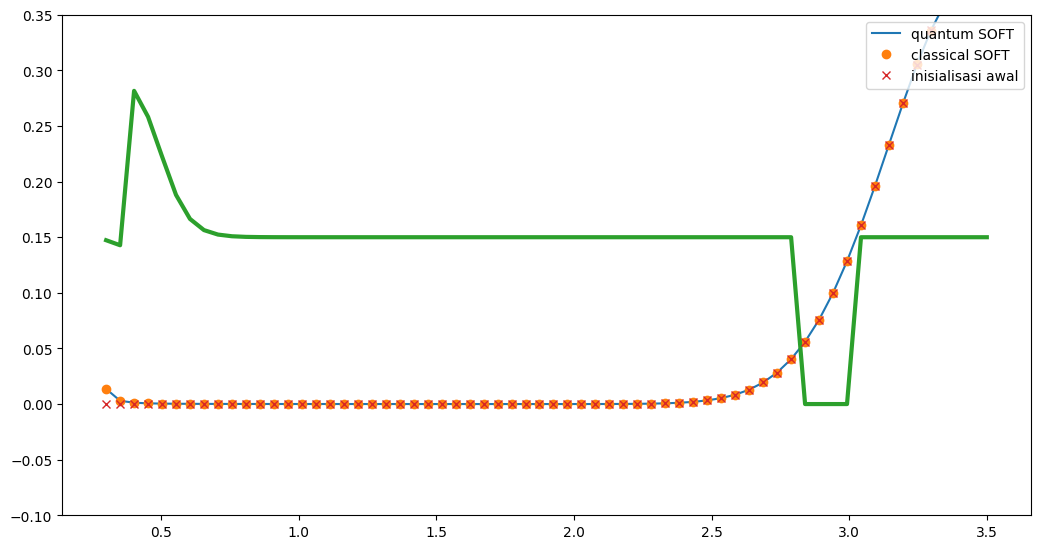

In [64]:
#plotting initial and final wavefunction
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = [12.50, 6.50]
#plt.plot(x, np.real(psin), label = 'real')
#plt.plot(x, np.imag(psin), label = 'imag')
plt.plot(x, np.abs(psin), label='quantum SOFT')
plt.plot(x, np.abs(psi_c), 'o', label='classical SOFT')
plt.plot(x, VV, linewidth=3)
plt.plot(x, abs(psi), 'x', label='inisialisasi awal')
leg = plt.legend(loc='upper right')
plt.ylim(-0.1, 0.35)
plt.show()